# 01 — Target Definition & Merge Audit

Audit the `nyt_bestseller` label produced by `EDA/book_success_merge.ipynb`
and verify the merge is healthy before any modelling.

**Input:** `data/merged_books.csv`  
**Outputs:** class-balance report, match-quality spot-check, year-cohort table

## Goals
1. Confirm row count is stable (matches GoodBooks baseline after pre-1931 filter)
2. Inspect match method breakdown (exact ISBN vs fuzzy vs unmatched)
3. Check class balance overall and by publication decade
4. Understand NYT signal richness: `weeks_on_list`, `best_rank_achieved`, `debut_rank`
5. Choose train/test cutoff year based on cohort balance
6. Confirm leakage columns are correlated with the label (validates the target)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

DATA_PATH = Path('..') / 'data' / 'merged_books.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)

(7983, 46)


,authors,average_rating,best_book_id,book_id,books_count,description,genres,goodreads_book_id,image_url,isbn,...,nyt_author,nyt_title_norm,nyt_author_norm,nyt_bestseller,weeks_on_list,best_rank_achieved,nyt_first_year,debut_rank,match_method,is_nyt_match
0,['Suzanne Collins'],4.34,2767052,1,272,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,"['young-adult', 'fiction', 'fantasy', 'science...",2767052,https://images.gr-assets.com/books/1447303603m...,439023483,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,unmatched,0
1,"['J.K. Rowling', 'Mary GrandPré']",4.44,3,2,491,Harry Potter's life is miserable. His parents ...,"['fantasy', 'fiction', 'young-adult', 'classics']",3,https://images.gr-assets.com/books/1474154022m...,439554934,...,J. K. Rowling,NaN,NaN,1,82,1.0,1998.0,16.0,fuzzy_title_author,1
2,['Stephenie Meyer'],3.57,41865,3,226,About three things I was absolutely positive.\...,"['young-adult', 'fantasy', 'romance', 'fiction...",41865,https://images.gr-assets.com/books/1361039443m...,316015849,...,NaN,NaN,NaN,0,0,NaN,NaN,NaN,unmatched,0


## 1. Merge audit

**Unit of analysis:** one row = one book (keyed by `gb_id`, sourced from GoodBooks-10k). Not
one row per edition or per author — `gb_id` uniqueness confirms no duplication at this level.

In [2]:
# gb_id must be unique — any duplication means the merge went wrong
assert df['gb_id'].is_unique, 'gb_id is not unique!'
print(f'Total rows: {len(df):,}')
print(f'Unique gb_id: {df["gb_id"].nunique():,}')
print()
print('Match method breakdown:')
print(df['match_method'].value_counts())

Total rows: 7,983
Unique gb_id: 7,983

Match method breakdown:
match_method
unmatched             6584
fuzzy_title_author     727
exact_isbn             672
Name: count, dtype: int64


## 2. Class balance

17.5% positive, ~4.7:1 negative:positive ratio. Moderate imbalance — not extreme enough to need
resampling, but every baseline and downstream model should use `class_weight='balanced'` (or
equivalent), and accuracy alone will be a misleading metric (prefer F1/precision/recall/ROC-PR
for imbalanced classes). 

No decade falls outside the 5–30% band, so temporal skew isn't an
additional confound. 

Positive rate rose from 15.1% pre-filter, as expected — box sets and
non-fiction rows were almost entirely negative-label, so removing them concentrates the
remaining positives.

Class balance:
nyt_bestseller
0    6584
1    1399
Name: count, dtype: int64

Positive rate: 17.5%


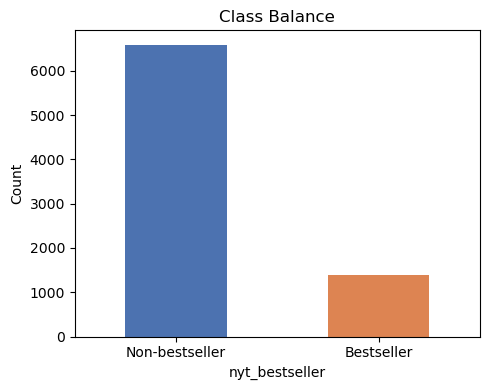

In [3]:
# Overall class balance
counts = df['nyt_bestseller'].value_counts().reindex([0, 1])
print('Class balance:')
print(counts)
print(f'\nPositive rate: {df["nyt_bestseller"].mean()*100:.1f}%')

# Bar chart — non-bestseller vs bestseller count
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['Non-bestseller', 'Bestseller'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Balance')
plt.tight_layout()
plt.show()

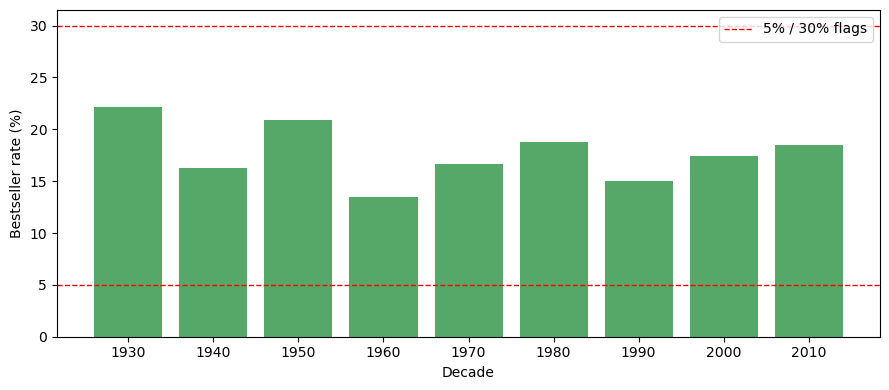

No decades flagged.



In [4]:
# Class balance by publication decade
df['pub_decade'] = (df['pub_year'] // 10 * 10).astype('Int64')

# Plot bestseller rate by decade — flag any decade with < 5% or > 30%
#       as potentially problematic for modelling

decade_stats = df.groupby('pub_decade')['nyt_bestseller'].agg(['mean', 'count'])
decade_stats['rate_pct'] = decade_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(decade_stats.index.astype(str), decade_stats['rate_pct'], color='#55A868')
ax.axhline(5, color='red', linestyle='--', linewidth=1, label='5% / 30% flags')
ax.axhline(30, color='red', linestyle='--', linewidth=1)
ax.set_ylabel('Bestseller rate (%)')
ax.set_xlabel('Decade')
ax.legend()
plt.tight_layout()
plt.show()

flagged = decade_stats[(decade_stats['rate_pct'] < 5) | (decade_stats['rate_pct'] > 30)]
print('Decades outside 5–30% band:' if len(flagged) else 'No decades flagged.')
print(flagged if len(flagged) else '')

## 3. NYT signal richness (bestsellers only)

In [5]:
bs = df[df['nyt_bestseller'] == 1]
print(f'Bestsellers: {len(bs):,}')
bs[['weeks_on_list', 'best_rank_achieved', 'debut_rank', 'nyt_first_year']].describe()

Bestsellers: 1,399


,weeks_on_list,best_rank_achieved,debut_rank,nyt_first_year
count,1399.000000,1399.000000,1399.000000,1399.000000
mean,11.461044,5.238027,6.822016,2000.502502
std,15.914373,4.338975,4.900051,17.158642
min,1.000000,1.000000,1.000000,1932.000000
25%,3.000000,1.000000,2.000000,1996.000000
50%,6.000000,4.000000,6.000000,2007.000000
75%,13.000000,8.000000,11.000000,2012.000000
max,178.000000,16.000000,16.000000,2018.000000


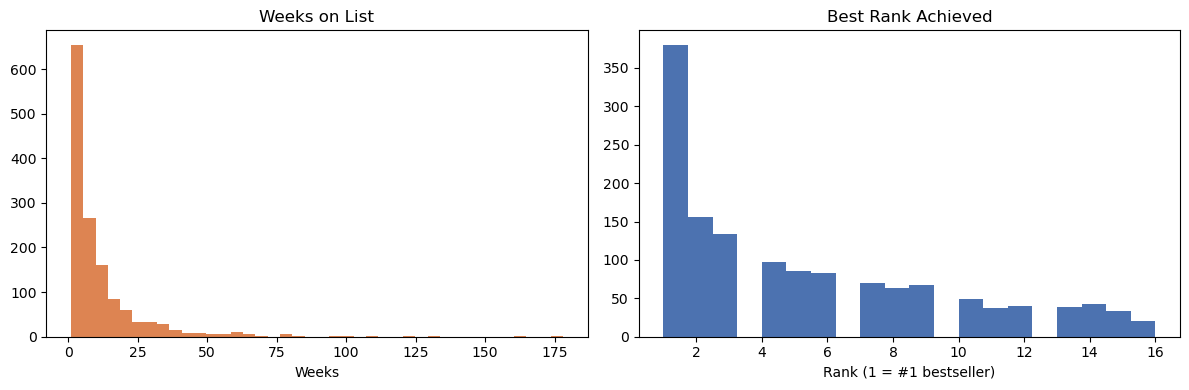

In [6]:
# NOTE: weeks_on_list and best_rank_achieved are valid for EDA but are
# NOT features — they are part of the outcome, not predictors

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bs['weeks_on_list'], bins=40, color='#DD8452')
axes[0].set_title('Weeks on List')
axes[0].set_xlabel('Weeks')

axes[1].hist(bs['best_rank_achieved'].dropna(), bins=20, color='#4C72B0')
axes[1].set_title('Best Rank Achieved')
axes[1].set_xlabel('Rank (1 = #1 bestseller)')
plt.tight_layout()
plt.show()

## 4. Choose train / test cutoff year

In [7]:
# Print book count and positive rate for several candidate cutoffs.
# Good cutoff: test set has >= 200 positives and >= 5% positive rate.

for cutoff in [2005, 2008, 2010, 2012, 2014]:
    train = df[df['pub_year'] < cutoff]
    test  = df[df['pub_year'] >= cutoff]
    test_pos = test['nyt_bestseller'].sum()
    test_rate = test['nyt_bestseller'].mean() * 100
    print(f'Cutoff {cutoff}: train={len(train):,}  test={len(test):,}  '
          f'test_pos={test_pos}  test_rate={test_rate:.1f}%')

Cutoff 2005: train=3,680  test=4,287  test_pos=818  test_rate=19.1%
Cutoff 2008: train=4,551  test=3,416  test_pos=653  test_rate=19.1%
Cutoff 2010: train=5,244  test=2,723  test_pos=503  test_rate=18.5%
Cutoff 2012: train=6,132  test=1,835  test_pos=353  test_rate=19.2%
Cutoff 2014: train=7,113  test=854  test_pos=194  test_rate=22.7%


### Cutoff year: 2010

**Decision:** train on books published before 2010, test on books published 2010 onward.

**Candidates evaluated** (test set must have ≥200 positives and ≥5% positive rate):

| Cutoff | Train n | Test n | Test positives | Test rate |
|---|---|---|---|---|
| 2005 | 3,680 | 4,287 | 818 | 19.1% |
| 2008 | 4,551 | 3,416 | 653 | 19.1% |
| **2010** | **5,244** | **2,723** | **503** | **18.5%** |
| 2012 | 6,132 | 1,835 | 353 | 19.2% |
| 2014 | 7,113 | 854 | 194 | 22.7% ❌ |

2014 is excluded again: 194 test positives, just under the 200 minimum

**Why 2010 over the other valid candidates:**

The EDA (`book_success_merge.ipynb`) showed that 2015–2017 has an inflated, unstable bestseller
rate (23% → 28%, on shrinking samples down to n=11 in 2017) — a GoodBooks-10k selection-bias
artifact, not a real trend. Every cutoff ≤2014 includes those years in its test set; what changes
is how much they *dominate* it:

| Cutoff | 2015–17 books in test | Share of test set |
|---|---|---|
| 2005 | 463 | ~11% |
| 2008 | 463 | ~14% |
| **2010** | **463** | **~17%** |
| 2012 | 463 | ~25% |

Weighed against 2005/2008
(which dilute the tail further but leave meaningfully less training data — 3,680–4,551 vs 5,244
books), 2010 remains the best balance: real training volume (66% of the data), a test set large
enough to be reliable (2,723 books, 503 positives), and a smaller (if less visibly dramatic)
exposure to the known selection-bias artifact in the most recent years.

In [8]:
# 4b. Check whether label quality (exact vs. fuzzy) is skewed across the chosen split
df['split'] = df['pub_year'].apply(lambda y: 'train' if pd.notna(y) and y < 2010 else 'test')
print('Match method share within train vs test (%):')
print((pd.crosstab(df['split'], df['match_method'], normalize='index') * 100).round(1))
print()
pos = df[df['nyt_bestseller'] == 1]
print('Match method share among POSITIVE labels only, by split (%):')
print((pd.crosstab(pos['split'], pos['match_method'], normalize='index') * 100).round(1))

Match method share within train vs test (%):


match_method  exact_isbn  fuzzy_title_author  unmatched
split                                                  
test                15.2                 3.4       81.5
train                4.9                12.1       83.0

Match method share among POSITIVE labels only, by split (%):


match_method  exact_isbn  fuzzy_title_author
split                                       
test                81.9                18.1
train               28.8                71.2


## 5. Leakage column sanity check

These columns **must not** enter the feature matrix, but we expect them to
correlate with `nyt_bestseller` — that confirms the label is picking up genuine
commercial success.

`ratings_count`, `work_ratings_count`, and `work_text_reviews_count` all correlate positively
with the label as expected (bestsellers get more engagement). 

`average_rating` goes the *other* direction (r=-0.18; median 3.92 for bestsellers vs. 4.04 for non-bestsellers) 
— commercial success and Goodreads community rating quality are somewhat decoupled in this data, likely
because mass-market commercial fiction rates lower with the more critical Goodreads community
than niche/literary favorites. This doesn't undermine the label; it's a reminder that "good on
Goodreads" and "bestseller" are different constructs.

average_rating               r=-0.185  p=1.2e-62
ratings_count                r=+0.062  p=3.0e-08
work_ratings_count           r=+0.067  p=2.7e-09
work_text_reviews_count      r=+0.092  p=1.5e-16


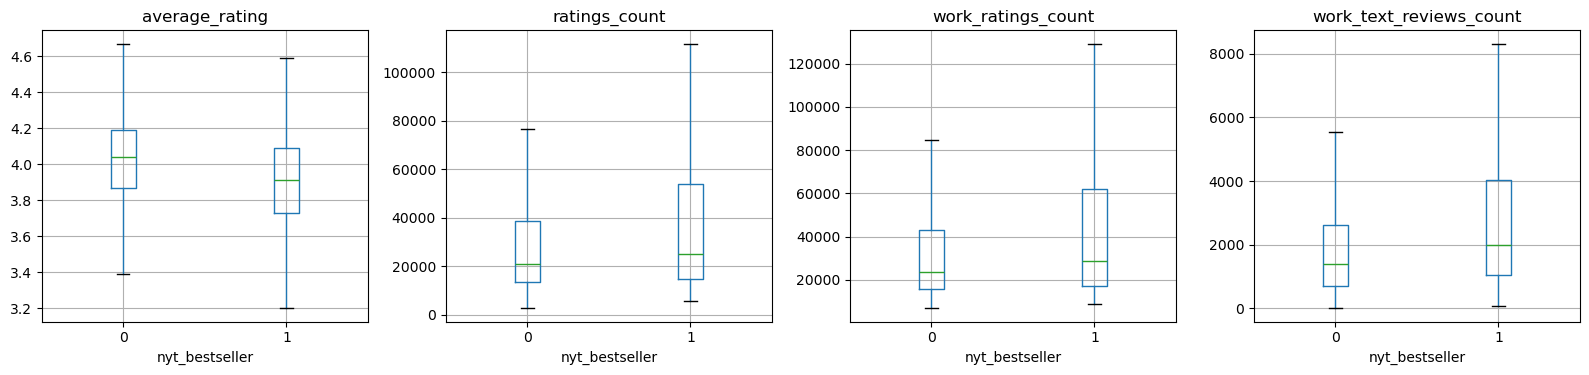

In [9]:
LEAKAGE_COLS = [
    'average_rating', 'ratings_count', 'work_ratings_count',
    'work_text_reviews_count',
]
leakage_present = [c for c in LEAKAGE_COLS if c in df.columns]

# Point-biserial correlation or boxplots of each leakage column vs nyt_bestseller
# ratings_count, work_ratings_count, work_text_reviews_count behave as expected -> Bestsellers get more engagement
# average_rating goes the other direction — bestsellers have a slightly lower median rating (3.92 vs 4.04), not higher, 
# and it's the strongest correlation of the four 


from scipy import stats

for col in leakage_present:
    sub = df[[col, 'nyt_bestseller']].dropna()
    r, p = stats.pointbiserialr(sub['nyt_bestseller'], sub[col])
    print(f'{col:28s} r={r:+.3f}  p={p:.1e}')

fig, axes = plt.subplots(1, len(leakage_present), figsize=(4*len(leakage_present), 4))
for ax, col in zip(axes, leakage_present):
    df.boxplot(column=col, by='nyt_bestseller', ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('nyt_bestseller')
plt.suptitle('')
plt.tight_layout()
plt.show()